### Processing with both Pandas and Dask

We want to compute the mean speed over all the time steps.

- With **Pandas**:
    - The 10 CSV files are iteratively loaded in memory and the mean speed for this step is computed
    - The global mean speed over all steps is computed (and the time elapsed to do this computed)


- With **Dask**:
    - A cluster of 4 workers (ie local processes) are created, ready to execute some work
    - The laziness of Dask is highlighted (the task graph to compute the mean is displayed
    - The mean is then actually computed and the time taken to do this is compared to the one taken by Pandas
    - An example of filtering is done
    - Two functions are to be computed over the new Dataframe: Mean and Standard deviation of the speed
    - The lazyiness of Dask is exploited to optimize the actual computation of the two functions
    - A parallel operation is applied on the dataframe

In [1]:
import pandas as pd
import dask.dataframe as dd
from statistics import mean

rounds = 10

filenames = ['boats_small'+str(i)+'.csv' for i in range(rounds)]

In [2]:
%%time

# first with pandas
dfs = []
speed_avgs = []
for fn in filenames:
    df = pd.read_csv(fn)
    dfs.append(df)
    speed_avgs.append(df["Speed"].mean())

global_speed_avgs = mean(speed_avgs)
global_speed_avgs

CPU times: user 14.3 ms, sys: 1.99 ms, total: 16.3 ms
Wall time: 16 ms


np.float64(7.53)

In [3]:
global_df = pd.concat(dfs)
global_df_filtered = global_df[global_df.ID == 5]
global_df_filtered

,Unnamed: 0,ID,Speed,Destination
5,5,5,9,CORK
5,5,5,7,CORK
5,5,5,8,CORK
5,5,5,12,CORK
5,5,5,11,CORK
5,5,5,12,CORK
5,5,5,9,CORK
5,5,5,12,CORK
5,5,5,7,CORK
5,5,5,6,CORK


In [4]:
from dask.distributed import Client

client = Client(n_workers=4)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 24,Total memory: 30.80 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45353,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44945,Total threads: 6
Dashboard: http://127.0.0.1:37309/status,Memory: 7.70 GiB
Nanny: tcp://127.0.0.1:38431,


In [5]:
# same with dask DataFrame


ddf = dd.read_csv('boats_small*.csv')
mean_speed = ddf["Speed"].mean()
mean_speed

<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(e864179))['Speed'].mean(), dtype=float64>

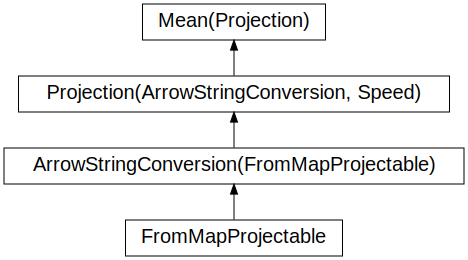

In [6]:
import graphviz
mean_speed.visualize()

In [7]:
%%time
mean_speed.compute()

CPU times: user 263 ms, sys: 22.2 ms, total: 285 ms
Wall time: 995 ms


np.float64(7.53)

In [8]:
ddf_filtered = ddf[ddf["Destination"] == "PALERMO"]
ddf_filtered

,Unnamed: 0,ID,Speed,Destination
npartitions=10,,,,
,int64,int64,int64,string
,...,...,...,...
...,...,...,...,...
,...,...,...,...
,...,...,...,...


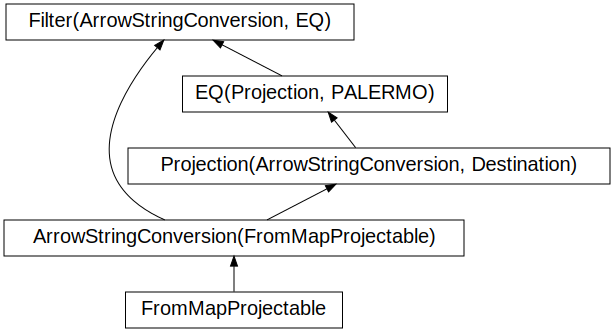

In [9]:
ddf_filtered.visualize()

In [10]:
ddf_filtered.compute()

,Unnamed: 0,ID,Speed,Destination
6,6,6,1,PALERMO
9,9,9,9,PALERMO
16,16,16,8,PALERMO
18,18,18,1,PALERMO
19,19,19,10,PALERMO
6,6,6,1,PALERMO
9,9,9,7,PALERMO
16,16,16,8,PALERMO
18,18,18,2,PALERMO
19,19,19,7,PALERMO


In [11]:
ddf_filtered_mean = ddf_filtered["Speed"].mean()
ddf_filtered_std = ddf_filtered["Speed"].std()
ddf_filtered_std

<dask_expr.expr.Scalar: expr=MapPartitions(sqrt), dtype=float64>

In [12]:
%%time
ddf_filtered_mean.compute()
ddf_filtered_std.compute()

CPU times: user 179 ms, sys: 17 ms, total: 196 ms
Wall time: 269 ms


np.float64(4.268011055204396)

In [13]:
import dask

In [14]:
%%time
dask.compute(ddf_filtered_mean, ddf_filtered_std)

CPU times: user 101 ms, sys: 7.1 ms, total: 108 ms
Wall time: 149 ms


(np.float64(6.22), np.float64(4.268011055204396))

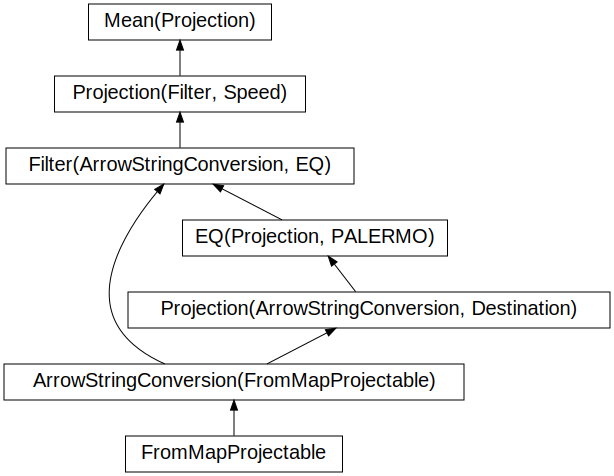

In [15]:
#dask.visualize(ddf_filtered_mean, ddf_filtered_std)
ddf_filtered_mean.visualize()

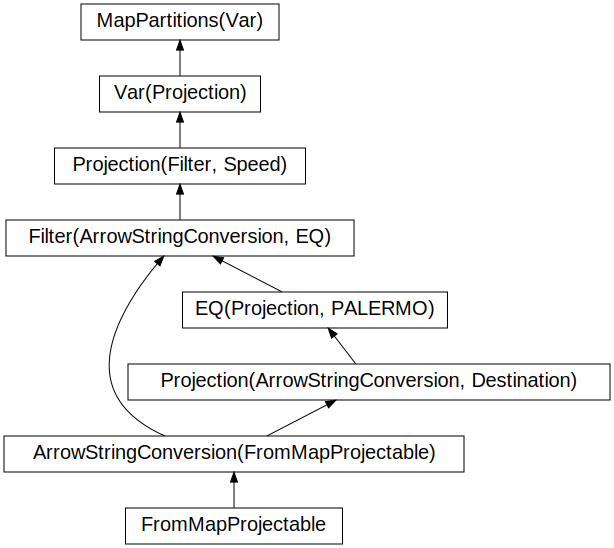

In [16]:
ddf_filtered_std.visualize()

In [17]:
def to_kmh(df):
    return(df.apply(lambda x: x * 1.852))

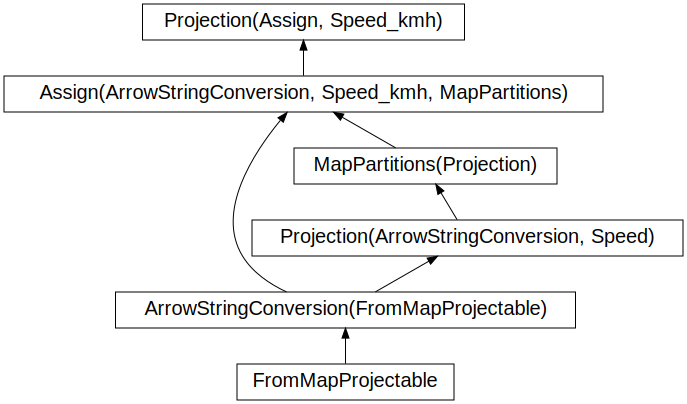

In [18]:
ddf["Speed_kmh"] = ddf["Speed"].map_partitions(to_kmh)
ddf["Speed_kmh"].visualize()

In [19]:
ddf.compute()

,Unnamed: 0,ID,Speed,Destination,Speed_kmh
0,0,0,8,BREST,14.816
1,1,1,9,VALENCIA,16.668
2,2,2,15,BRIGHTON,27.780
3,3,3,5,STOCKHOLM,9.260
4,4,4,7,CORK,12.964
...,...,...,...,...,...
15,15,15,6,BRIGHTON,11.112
16,16,16,7,PALERMO,12.964
17,17,17,13,VALENCIA,24.076
18,18,18,3,PALERMO,5.556


In [20]:
client.shutdown()